## Overview
This notebook implements an automated pipeline to solve the **ML-CUP25 Regression Task** using an **Ensemble of Small Models**.

## Workflow
1.  **Data Loading**: 
    - Loads `ML-CUP25-TR.csv` and splits it into **Train**, **Validation** (20%), and **Blind Test**.

2.  **Architecture Search (Optuna)**: 
    - We use **Optuna** to find the best hyperparameters for a *single* small model.
    - **Constraints**: 
        - Depth: 1 to 2 hidden layers.
        - Width: 8 to 64 neurons per layer.
    - **Goal**: Minimize MSE on the Validation Set.

3.  **Ensemble Training**: 
    - We take the *best* architecture found by Optuna.
    - We instantiate **5 independent copies** of this model (the "Ensemble").
    - Each copy is trained from scratch with different random initializations.

4.  **Final Evaluation**:
    - The ensemble's prediction is the **average** of all 5 members.
    - We report the final MSE on the Validation and Test sets.

## How to Use
1.  **Prerequisites**: Ensure `data_loader.py` and the `models/` folder are in the same directory.
2.  **Configuration**: Adjust the constants in the first code cell (e.g., `N_TRIALS`, `ENSEMBLE_SIZE`) to control runtime.
3.  **Run All**: Execute all cells in order. The Optuna search will run first, followed automatically by the ensemble training.

In [2]:
#--- 0. IMPORTS ---

import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ensure we can import from local modules
sys.path.append(os.getcwd())

# Import your custom modules
from data_loader import get_ml_cup_data
from models import StandardFeedForwardNet, EnsembleModel
from models.ensemble import ModelWithHead, ReadoutAdapter
import training_utils

# --- CONFIGURATION ---
N_TRIALS = 1000
N_EPOCHS_SEARCH = 35
BATCH_SIZE = 64
N_EPOCHS_FINAL = 300 # Train the final ensemble longer
ENSEMBLE_SIZE = 10   # How many models to stack together
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {DEVICE}")

c:\Users\Michael\Desktop\Rage-Against-ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [3]:
# --- 1. DATA LOADING ---
# train_loader, val_loader, test_loader, input_size, output_size

train_loader, val_loader, test_loader, blind_test_loader, INPUT_SIZE, OUTPUT_SIZE, target_scaler = get_ml_cup_data(
    BATCH_SIZE, 
    # validation=True,  <-- REMOVE THIS LINE
    validation_ratio=0.20,
    scale_target=True,
    num_workers=0  # Good for Windows multiprocessing stability
)

print(f"Data Loaded. Input Size: {INPUT_SIZE}, Output Size: {OUTPUT_SIZE}")
print(f"Train Batches: {len(train_loader)}, Val Batches: {len(val_loader)}")

Parsing ML-CUP data...
Data Split: Train=350, Val=100, Internal Test=50 (Blind Test=1000)
Applying scaling StandardScaler to Inputs...
Applying StandardScaler to Targets...
Data Loaded. Input Size: 12, Output Size: 4
Train Batches: 6, Val Batches: 2


In [5]:
# --- 2. OPTUNA OBJECTIVE ---

def train_evaluate_model(params, train_loader, val_loader, epochs, device):
    """Helper to build, train and eval a single model for Optuna."""
    
    # Extract Params
    hidden_sizes = params['hidden_sizes']
    act = params['activation']
    lr = params['lr']
    model_type = params['model_type']
    
    base = StandardFeedForwardNet(INPUT_SIZE, hidden_sizes, OUTPUT_SIZE, act)
    
    # Wrap it to ensure compatibility with the Ensemble logic later
    model = ModelWithHead(base, ReadoutAdapter(OUTPUT_SIZE, OUTPUT_SIZE, 'regression')).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Short Training Loop
    for epoch in range(epochs):
        model.train()
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            optimizer.step()
            
    # Evaluate on Validation Set
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            out = model(data)
            total_loss += criterion(out, target).item()
            
    return total_loss / len(val_loader)

def objective(trial):
    # --- Search Space ---
    n_layers = trial.suggest_int("n_layers", 1, 2)
    hidden_sizes = [trial.suggest_int(f"units_l{i}", 8, 64) for i in range(n_layers)]
        
    params = {
        'model': trial.suggest_categorical("model_type", ["standard"]),
        'hidden_sizes': hidden_sizes,
        'activation': trial.suggest_categorical("activation", ["relu", "tanh", "gelu"]),
        'lr': trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    }
    
    # Use the utility! 
    # Note: We create a fresh model for every trial inside the utility logic
    model = training_utils.build_model(params, INPUT_SIZE, OUTPUT_SIZE, DEVICE, is_regression=True)
    optimizer = optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.MSELoss()
    
    # Training Loop
    for epoch in range(N_EPOCHS_SEARCH):
        training_utils.train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        
    # Final Validation
    val_mse = training_utils.evaluate(model, val_loader, criterion, DEVICE, target_scaler=target_scaler)
    return val_mse

In [10]:
# --- 3. RUN OPTUNA SEARCH & ANALYZE TOP 5 ---
import sys
import optuna
import pandas as pd
from IPython.display import display

# 1. Run the external script
# The script now self-cleans the lock upon exit
!{sys.executable} optuna_search.py --n_trials {N_TRIALS} --epochs {N_EPOCHS_SEARCH}

# 2. Access Results Safely
# We use a separate storage object so we can dispose of it explicitly
db_url = "sqlite:///optuna.db"
storage = optuna.storages.RDBStorage(url=db_url)

try:
    study = optuna.load_study(
        study_name="mlcup_search",
        storage=storage
    )

    # 3. Filter and Sort for the Top 5 Models
    df = study.trials_dataframe()
    df = df[df.state == "COMPLETE"]
    top_5 = df.sort_values('value', ascending=True).head(5)
    cols_to_show = ['number', 'value'] + [c for c in df.columns if c.startswith('params_')]

    print(f"\nSearch Complete. Best Params: {study.best_params}")
    print("\n--- TOP 5 BEST ARCHITECTURES FOUND ---")
    display(top_5[cols_to_show])
    
    # Store best params in a variable before closing study
    best_params = study.best_params

finally:
    # --- Release the file lock ---
    print("Disposing storage engine to release file lock...")
    storage.engine.dispose()
    del storage

^C

Search Complete. Best Params: {'n_layers': 3, 'hidden_size': 1521, 'dropout': 0.15226637823437422, 'weight_decay': 1.7129303300558341e-06, 'activation': 'relu', 'lr': 0.0009342414482819597}

--- TOP 5 BEST ARCHITECTURES FOUND ---


,number,value,params_activation,params_dropout,params_hidden_size,params_lr,params_n_layers,params_weight_decay
1926,1926,137.442131,relu,0.152266,1521,0.000934,3,0.000002
2244,2244,137.931496,relu,0.133928,1298,0.001427,3,0.000001
1769,1769,141.518478,relu,0.184476,1688,0.001209,3,0.000001
1340,1340,142.401817,relu,0.268900,2039,0.000613,3,0.000018
1906,1906,144.262817,relu,0.177514,1670,0.000803,3,0.000002


Disposing storage engine to release file lock...


In [11]:
# --- IMPORTS FOR DIRECT INSTANTIATION ---
import copy
from tqdm import tqdm
from models.standard import StandardFeedForwardNet
from models.ensemble import ModelWithHead, ReadoutAdapter
from models.ensemble import EnsembleModel

print(f"\nTraining Ensemble of {ENSEMBLE_SIZE} models with best configuration...")

# 1. Detect Architecture & Extract Params
params = study.best_params

# We are forcing Standard MLP now
model_type = "standard" 
lr = params['lr']
weight_decay = params.get('weight_decay', 0.0)

print(f"Detected Architecture: {model_type.upper()} (Wide MLP)")

members = []
optimizers = []

for i in range(ENSEMBLE_SIZE):
    # 2. Instantiate Base Model
    # Reconstruct list of hidden sizes based on the new search logic
    n_layers = params['n_layers']
    hidden_size = params['hidden_size']
    hidden_sizes = [hidden_size] * n_layers
    
    base = StandardFeedForwardNet(
        input_size=INPUT_SIZE,
        hidden_sizes=hidden_sizes,
        output_size=OUTPUT_SIZE,
        activation=params['activation'],
        dropout=params.get('dropout', 0.0)
    )

    # 3. Wrap with Head (for Ensemble consistency)
    model = ModelWithHead(base, ReadoutAdapter(OUTPUT_SIZE, OUTPUT_SIZE, 'regression')).to(DEVICE)
    members.append(model)

    # 4. Setup Optimizer (AdamW is standard now)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    optimizers.append(opt)

# 5. Create the Ensemble Container
ensemble = EnsembleModel(members, weights=[1.0]*ENSEMBLE_SIZE).to(DEVICE)
criterion = nn.MSELoss()

train_losses = []
val_mses = []

# --- CHECKPOINTING INIT ---
best_ensemble_mse = float('inf')
best_epoch = -1
best_member_weights = [None] * ENSEMBLE_SIZE 

# Progress Bar
pbar = tqdm(range(N_EPOCHS_FINAL), desc="Training Ensemble", unit="epoch")

for epoch in pbar:
    ensemble.train() 
    total_loss = 0
    
    # --- TRAINING (On Scaled Data) ---
    for data, target in train_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        
        batch_loss = 0
        for model, opt in zip(members, optimizers):
            opt.zero_grad()
            out = model(data)
            loss = criterion(out, target)
            loss.backward()
            opt.step()
            batch_loss += loss.item()
        
        total_loss += batch_loss / ENSEMBLE_SIZE
        
    current_train_loss = total_loss / len(train_loader)
    train_losses.append(current_train_loss)
    
    # --- VALIDATION (On Unscaled/Real Data) ---
    current_val_mse = training_utils.evaluate(
        ensemble, 
        val_loader, 
        criterion, 
        DEVICE, 
        target_scaler=target_scaler
    )
    val_mses.append(current_val_mse)
    
    # --- CHECKPOINTING LOGIC ---
    if current_val_mse < best_ensemble_mse:
        best_ensemble_mse = current_val_mse
        best_epoch = epoch
        
        for i, model in enumerate(members):
            best_member_weights[i] = copy.deepcopy({k: v.cpu() for k, v in model.state_dict().items()})
            
        pbar.set_postfix({
            'Train': f"{current_train_loss:.4f}",
            'Val': f"{current_val_mse:.4f}",
            'Best': f"{best_ensemble_mse:.4f} (*)"
        })
    else:
        pbar.set_postfix({
            'Train': f"{current_train_loss:.4f}",
            'Val': f"{current_val_mse:.4f}",
            'Best': f"{best_ensemble_mse:.4f}"
        })

# --- RESTORE BEST WEIGHTS ---
print(f"\nTraining finished. Restoring best model from Epoch {best_epoch} (MSE: {best_ensemble_mse:.4f})...")

for i, model in enumerate(members):
    model.load_state_dict(best_member_weights[i])
    model.to(DEVICE)

print("Best ensemble weights restored and ready for testing.")


Training Ensemble of 10 models with best configuration...
Detected Architecture: STANDARD (Wide MLP)


Training Ensemble: 100%|██████████| 300/300 [12:01<00:00,  2.41s/epoch, Train=0.0233, Val=150.9038, Best=135.4091]   


Training finished. Restoring best model from Epoch 61 (MSE: 135.4091)...
Best ensemble weights restored and ready for testing.



Plotting convergence graph...


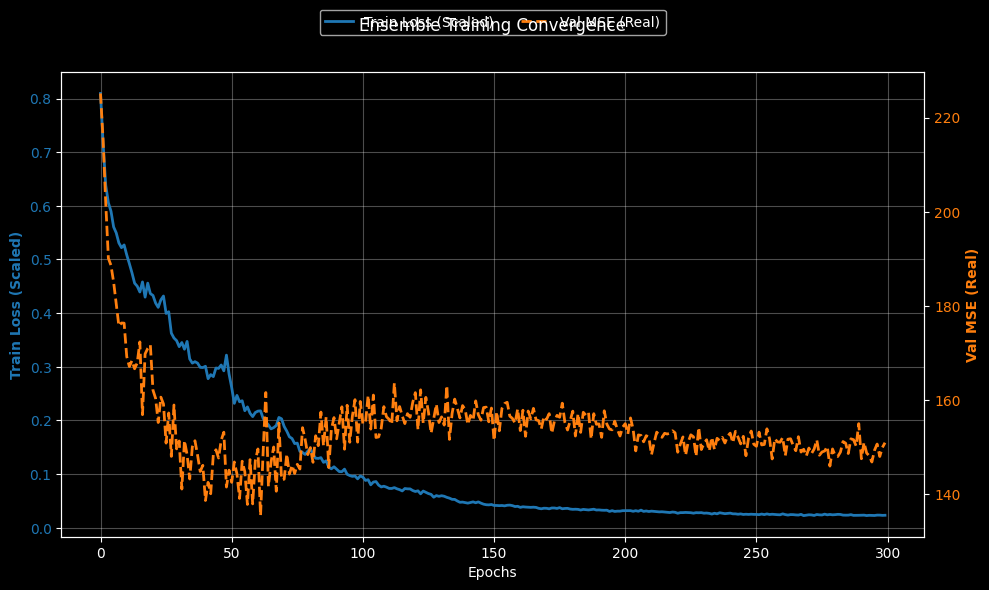

In [12]:
import matplotlib.pyplot as plt

# --- 5. PLOT CONVERGENCE ---
print("\nPlotting convergence graph...")

plt.figure(figsize=(10, 6))
ax1 = plt.gca()

# Plot Training Loss (Scaled) on Left Y-Axis
color = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Train Loss (Scaled)', color=color, fontweight='bold')
line1 = ax1.plot(train_losses, color=color, label='Train Loss (Scaled)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create Second Y-Axis for Validation MSE (Real)
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Val MSE (Real)', color=color, fontweight='bold')
line2 = ax2.plot(val_mses, color=color, label='Val MSE (Real)', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

plt.title('Ensemble Training Convergence', pad=30)
plt.tight_layout()

plt.show()

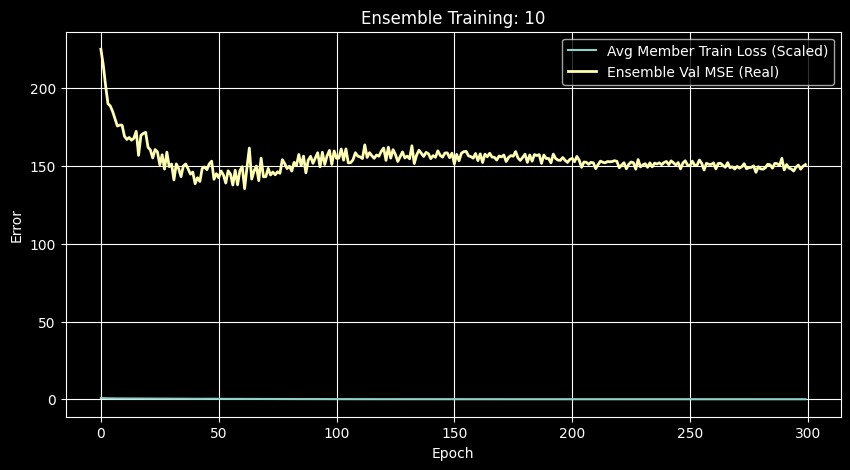

Evaluating Ensemble on Internal Test Set...

FINAL TEST RESULT (Unscaled)
Mean Euclidean Error (MEE): 18.4797
Target Range (Y1): -32.53741 to 25.742863
Target Range (Y2): -31.705093 to 27.652477
Target Range (Y3): -61.216526 to 41.88947
Target Range (Y4): -39.696476 to 43.891903


Loading data on cpu...
Parsing ML-CUP data...
Data Split: Train=350, Val=100, Internal Test=50 (Blind Test=1000)
Applying scaling StandardScaler to Inputs...
Applying StandardScaler to Targets...
Starting Wide-MLP Search: Trials=1000, Epochs=35
Search complete.
Releasing database lock...


In [13]:
# --- 6. RESULTS, PLOT & MEE CALCULATION ---
import numpy as np

# 1. Plot Training History
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Avg Member Train Loss (Scaled)')
plt.plot(val_mses, label='Ensemble Val MSE (Real)', linewidth=2)
plt.title(f"Ensemble Training: {ENSEMBLE_SIZE}")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

# 2. Final Evaluation on INTERNAL TEST SET (MEE Calculation)
print("Evaluating Ensemble on Internal Test Set...")

ensemble.eval()
total_mee = 0.0
total_samples = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        
        # Get ensemble predictions (already averaged inside the model)
        out = ensemble(data)
        
        # --- INVERSE TRANSFORM TO REAL UNITS ---
        # Move to CPU and numpy
        out_np = out.cpu().numpy()
        target_np = target.cpu().numpy()
        
        # Inverse transform to get physical values
        out_real = target_scaler.inverse_transform(out_np)
        target_real = target_scaler.inverse_transform(target_np)
        
        # --- CALCULATE MEE (Mean Euclidean Error) ---
        # 1. Difference vector
        diff = out_real - target_real
        
        # 2. Euclidean distance for each sample: sqrt(sum(diff^2))
        # axis=1 sums across the output dimensions (e.g., x and y coordinates)
        euclidean_dists = np.sqrt(np.sum(diff**2, axis=1))
        
        # 3. Accumulate sum of distances
        total_mee += np.sum(euclidean_dists)
        total_samples += data.size(0)

# Final Average
final_mee = total_mee / total_samples

print("\n" + "="*40)
print(f"FINAL TEST RESULT (Unscaled)")
print(f"Mean Euclidean Error (MEE): {final_mee:.4f}")
print("="*40)
# Check the range of the REAL targets in the test set
print("Target Range (Y1):", target_real[:, 0].min(), "to", target_real[:, 0].max())
print("Target Range (Y2):", target_real[:, 1].min(), "to", target_real[:, 1].max())
print("Target Range (Y3):", target_real[:, 2].min(), "to", target_real[:, 2].max())
print("Target Range (Y4):", target_real[:, 3].min(), "to", target_real[:, 3].max())
print("="*40)

In [ ]:
# --- 7. VISUAL INSPECTION (PRED VS TRUE) ---
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("Generating predictions for visual inspection...")

ensemble.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        
        # Get predictions
        out = ensemble(data)
        
        # Move to CPU
        all_preds.append(out.cpu().numpy())
        all_targets.append(target.cpu().numpy())

# Concatenate all batches
all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

# Inverse Transform to get Real Values
real_preds = target_scaler.inverse_transform(all_preds)
real_targets = target_scaler.inverse_transform(all_targets)

# --- 1. PRINT TABLE OF FIRST 10 SAMPLES ---
print("\n--- Sample Comparison (First 10) ---")
# Create a DataFrame for nice printing
df_compare = pd.DataFrame({
    'True_Y1': real_targets[:10, 0],
    'Pred_Y1': real_preds[:10, 0],
    'Diff_Y1': real_targets[:10, 0] - real_preds[:10, 0],
    'True_Y2': real_targets[:10, 1],
    'Pred_Y2': real_preds[:10, 1],
    'Diff_Y2': real_targets[:10, 1] - real_preds[:10, 1]
})
print(df_compare.round(4).to_string())

# --- 2. SCATTER PLOTS ---
plt.figure(figsize=(14, 6))

# Plot for Output 1
plt.subplot(1, 2, 1)
plt.scatter(real_targets[:, 0], real_preds[:, 0], alpha=0.5, color='blue', label='Samples')
# Draw perfect diagonal line
min_val = min(real_targets[:, 0].min(), real_preds[:, 0].min())
max_val = max(real_targets[:, 0].max(), real_preds[:, 0].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.title("Output 1: True vs Predicted")
plt.xlabel("True Value")
plt.ylabel("Predicted Value")
plt.legend()
plt.grid(True)

# Plot for Output 2
plt.subplot(1, 2, 2)
plt.scatter(real_targets[:, 1], real_preds[:, 1], alpha=0.5, color='green', label='Samples')
# Draw perfect diagonal line
min_val = min(real_targets[:, 1].min(), real_preds[:, 1].min())
max_val = max(real_targets[:, 1].max(), real_preds[:, 1].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.title("Output 2: True vs Predicted")
plt.xlabel("True Value")
plt.ylabel("Predicted Value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()